# Employee Attrition Prediction using Machine Learning

**A Data-Driven Case Study for HR Leadership**

---

**Author:** Nasrulla Shaik
**Dataset:** IBM HR Analytics Employee Attrition Dataset
**Objective:** Build a machine learning model that predicts which employees are likely to leave the company, and translate the model's findings into concrete, actionable recommendations for HR leadership.

---

## Table of Contents

1. [Introduction & Business Context](#1.-Introduction-&-Business-Context)
2. [Data Loading & Exploration](#2.-Data-Loading-&-Exploration)
3. [Data Cleaning & Preprocessing](#3.-Data-Cleaning-&-Preprocessing)
4. [Exploratory Data Analysis (EDA)](#4.-Exploratory-Data-Analysis-(EDA))
5. [Model Building](#5.-Model-Building)
6. [Model Evaluation](#6.-Model-Evaluation)
7. [Chart Exports](#7.-Chart-Exports)
8. [Business Recommendations](#8.-Business-Recommendations)
9. [Conclusion](#9.-Conclusion)
10. [References](#10.-References)


## 1. Introduction & Business Context

Employee attrition — when employees voluntarily leave a company — is one of the most expensive and disruptive problems an organization can face. Replacing a single employee typically costs between half and two times their annual salary once recruiting, onboarding, lost productivity, and knowledge transfer are accounted for.

**The business question this notebook answers:**

> *Can we predict, in advance, which employees are at the highest risk of leaving — and what is actually driving that risk?*

A model that answers this question lets HR move from a **reactive** posture (reacting to resignations after they happen) to a **proactive** one (intervening with at-risk employees before they decide to leave).

**Why this matters financially:** if HR can identify the 15-20% of employees who are most likely to leave and successfully retain even a fraction of them through targeted interventions (pay adjustments, role changes, manager coaching), the cost savings from avoided turnover can run into hundreds of thousands of dollars per year for a mid-sized organization.

This notebook follows a complete, production-style data science workflow:

1. Load and explore the raw HR data
2. Clean and prepare it for modeling, carefully avoiding data leakage
3. Explore the data visually to surface business-relevant patterns
4. Train and tune multiple classification models
5. Evaluate those models using metrics appropriate for an imbalanced HR problem
6. Translate the best model's findings into HR policy recommendations


## 2. Data Loading & Exploration

I start by loading the dataset and getting a first look at its structure: how many records and columns it has, what types of data it contains, and how balanced our target variable (`Attrition`) is.

Understanding the shape and balance of the data **before** doing anything else is essential — it directly informs which preprocessing steps, modeling choices, and evaluation metrics will be appropriate later on.

In [1]:
# -----------------------------------------------------------------
# Imports
# -----------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import os
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

# -----------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------------------------------------------------
# Plotting style
# -----------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

# -----------------------------------------------------------------
# Output folder for saved charts
# -----------------------------------------------------------------
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

print("Libraries imported successfully.")
print(f"Random seed set to {RANDOM_STATE} for reproducibility.")

Libraries imported successfully.
Random seed set to 42 for reproducibility.


### 2.1 Loading the Dataset

The dataset is the well-known **IBM HR Analytics Employee Attrition** dataset, distributed as a single CSV file. It contains demographic, job-related, and satisfaction data for 1,470 employees, along with a label for whether each employee left the company (`Attrition`).

In [2]:
# Load the dataset
DATA_PATH = "data.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully from '{DATA_PATH}'.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully from 'data.csv'.
Shape: 1470 rows x 35 columns


### 2.2 First Look at the Data

In [3]:
# Display the first 10 rows to get a feel for the data
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### 2.3 Dataset Shape and Data Types

In [4]:
print(f"Number of rows (employees):  {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")
print()
print("Data types of each column:")
print(df.dtypes)

Number of rows (employees):  1470
Number of columns (features): 35

Data types of each column:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours        

### 2.4 Target Variable: Attrition

`Attrition` is our target — it tells us whether an employee left the company (`Yes`) or stayed (`No`). Let's quantify exactly how many employees fall into each group, and what fraction of the workforce that represents.

In [5]:
# Count of employees who stayed vs. left
attrition_counts = df["Attrition"].value_counts()
employees_stayed = attrition_counts.get("No", 0)
employees_left = attrition_counts.get("Yes", 0)
total_employees = len(df)
attrition_pct = (employees_left / total_employees) * 100

print(f"Employees who stayed (No):  {employees_stayed}")
print(f"Employees who left (Yes):   {employees_left}")
print(f"Total employees:            {total_employees}")
print(f"Attrition rate:             {attrition_pct:.2f}%")

Employees who stayed (No):  1233
Employees who left (Yes):   237
Total employees:            1470
Attrition rate:             16.12%


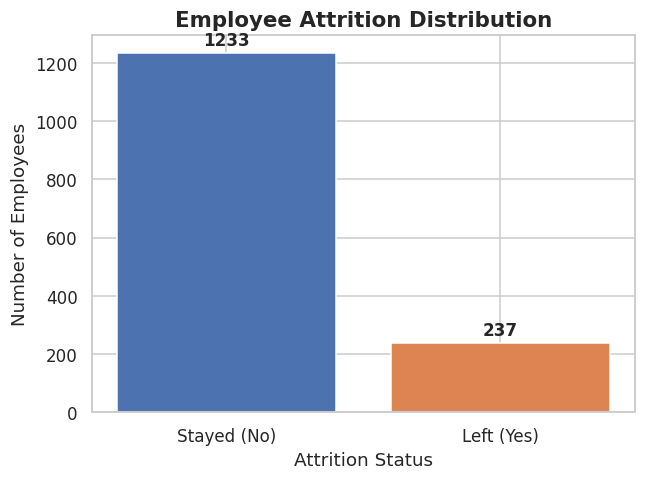

In [6]:
# Visualize the target distribution
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(["Stayed (No)", "Left (Yes)"], [employees_stayed, employees_left], color=colors)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")

ax.set_title("Employee Attrition Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Employees")
ax.set_xlabel("Attrition Status")
plt.tight_layout()
plt.show()

### 2.5 Identifying Numerical and Categorical Columns

Separating numerical from categorical columns now will guide our preprocessing strategy: numerical columns will be scaled, and categorical columns will be one-hot encoded.

In [7]:
# Identify categorical columns (object/string dtype)
categorical_cols = df.select_dtypes(include="object").columns.tolist()

# Identify numerical columns (everything else)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)
print()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### 2.6 Business Observation: Class Balance

**Is the target balanced or imbalanced?**

With roughly **16% of employees leaving** and **84% staying**, this is a **moderately imbalanced classification problem** — not extreme (like fraud detection at <1%), but imbalanced enough that it has real modeling consequences:

- **Accuracy becomes a misleading metric.** A model that simply predicts "No" (stays) for every single employee would already be correct about 84% of the time, while being completely useless for the actual business goal of identifying at-risk employees.
- **Models will naturally be biased toward the majority class** unless we explicitly correct for it. Algorithms that minimize overall error will, by default, learn to favor predicting "stays" because it's right more often.
- **I must prioritize Recall and F1-score for the "Attrition = Yes" class, not just Accuracy.** From an HR perspective, failing to flag an employee who is about to leave (a false negative) is usually more costly than flagging an employee who was never going to leave (a false positive) — the cost of a missed resignation is replacement cost, lost productivity, and knowledge loss, whereas the cost of a false alarm is just one unnecessary retention conversation.
- **I will use `class_weight="balanced"`** in our linear and tree-based models, and **stratified train/test splitting**, to make sure the minority class (employees who leave) is properly represented during training and evaluation.

## 3. Data Cleaning & Preprocessing

Before any modeling can happen, the data needs to be cleaned and transformed into a numeric format that machine learning algorithms can use. This section covers:

1. Checking for missing values
2. Removing columns that carry no predictive information (constant values or unique IDs)
3. Encoding the target variable
4. One-hot encoding categorical features
5. Splitting the data into training and test sets
6. Scaling numerical features — **fit only on training data** to avoid data leakage

### 3.1 Checking for Missing Values

In [8]:
missing_values = df.isnull().sum()
missing_summary = missing_values[missing_values > 0]

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values found:")
    print(missing_summary)

No missing values found in the dataset.


**Why this matters:** this dataset turns out to be complete, with zero missing values across all 1,470 records and 35 columns. In a real-world HR system this is unusually clean — in practice we would still write this check into any production pipeline, since new data pulled from an HRIS system in the future could easily contain missing fields (e.g., a new hire who hasn't had a performance review yet). Had missing values been present, the appropriate strategy would depend on the column: median imputation for skewed numerical fields, mode imputation for categorical fields, and likely row-removal for missingness in the target itself.

### 3.2 Removing Non-Informative Columns

Some columns carry no predictive signal at all:

- **`EmployeeNumber`** — a unique identifier for each employee. It's effectively a row index and would cause the model to "memorize" individuals rather than learn generalizable patterns.
- **`Over18`** — every employee in this dataset is over 18, so this column has only one unique value and contributes zero information.
- **`StandardHours`** — also constant across all employees (everyone is recorded at 80 hours), so it cannot help distinguish who leaves from who stays.
- **`EmployeeCount`** — constant at 1 for every row (an artifact of how the source HR system exports data), again carrying no signal.

We detect these automatically rather than hardcoding the list, so the notebook adapts if the underlying HR export changes.

In [9]:
# Automatically detect constant columns (only 1 unique value) — these carry zero signal
constant_columns = [col for col in df.columns if df[col].nunique() == 1]

# Known identifier columns to drop regardless of cardinality
known_identifier_columns = ["EmployeeNumber"]

columns_to_drop = sorted(set(constant_columns + known_identifier_columns) & set(df.columns))

print("Constant columns detected automatically:", constant_columns)
print("Identifier columns flagged manually:    ", known_identifier_columns)
print("Final list of columns to drop:          ", columns_to_drop)

df_clean = df.drop(columns=columns_to_drop)
print(f"\nShape before dropping: {df.shape}")
print(f"Shape after dropping:  {df_clean.shape}")

Constant columns detected automatically: ['EmployeeCount', 'Over18', 'StandardHours']
Identifier columns flagged manually:     ['EmployeeNumber']
Final list of columns to drop:           ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Shape before dropping: (1470, 35)
Shape after dropping:  (1470, 31)


### 3.3 Encoding the Target Variable

I convert the `Attrition` column from text (`Yes`/`No`) to a binary numeric value (`1`/`0`), which is the format scikit-learn classifiers expect.

In [10]:
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})

print("Target variable encoded:")
print(df_clean["Attrition"].value_counts())
print("\n1 = Employee left the company")
print("0 = Employee stayed at the company")

Target variable encoded:
Attrition
0    1233
1     237
Name: count, dtype: int64

1 = Employee left the company
0 = Employee stayed at the company


### 3.4 One-Hot Encoding Categorical Features

The remaining categorical columns (e.g., `Department`, `JobRole`, `OverTime`) are text labels with no inherent numeric order, so I use **one-hot encoding** to convert each category into its own binary (0/1) column. This avoids implying a false ordinal relationship between categories (e.g., it would be wrong to encode `Department` as 1, 2, 3, since "Sales" is not mathematically "less than" "R&D").

I use `drop_first=True` to avoid the "dummy variable trap" — keeping one fewer column per categorical feature than the number of categories, since the dropped category is implicitly represented when all the others are 0.

In [11]:
# Re-identify categorical columns on the cleaned dataframe (Attrition is now numeric, so it's excluded automatically)
categorical_cols_clean = df_clean.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to one-hot encode: {categorical_cols_clean}")

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols_clean, drop_first=True)

print(f"\nShape before encoding: {df_clean.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
print(f"({df_encoded.shape[1] - df_clean.shape[1]} new dummy columns created)")

Categorical columns to one-hot encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']



Shape before encoding: (1470, 31)
Shape after encoding:  (1470, 45)
(14 new dummy columns created)


### 3.5 Train/Test Split

I split the data into training (80%) and test (20%) sets **before** any scaling is applied. This ordering matters: if we were to scale the full dataset first and split afterward, information from the test set (its mean and standard deviation) would leak into the training process, giving an overly optimistic — and dishonest — estimate of how well the model will perform on truly unseen data.

I use `stratify=y` to ensure both the training and test sets preserve the same ~16% attrition rate found in the full dataset. Without stratification, a random split could accidentally produce a test set with very few "Yes" cases, making evaluation metrics unreliable.

In [12]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

# Stratified 80/20 split, fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} employees ({X_train.shape[0] / len(X):.1%})")
print(f"Test set:     {X_test.shape[0]} employees ({X_test.shape[0] / len(X):.1%})")
print()
print(f"Attrition rate in training set: {y_train.mean():.2%}")
print(f"Attrition rate in test set:     {y_test.mean():.2%}")
print(f"Attrition rate in full dataset: {y.mean():.2%}")

Training set: 1176 employees (80.0%)
Test set:     294 employees (20.0%)

Attrition rate in training set: 16.16%
Attrition rate in test set:     15.99%
Attrition rate in full dataset: 16.12%


### 3.6 Scaling Numerical Features (Leakage-Safe)

Algorithms like Logistic Regression are sensitive to the *scale* of input features — a feature like `MonthlyIncome` (ranging into the thousands) would dominate a feature like `JobSatisfaction` (ranging 1-4) purely because of its larger numeric range, not because it's more predictive. **Standardization** (subtracting the mean and dividing by the standard deviation) puts all numerical features on a comparable scale.

**To avoid data leakage, the `StandardScaler` is `fit()` only on the training data.** The test data is then transformed using the *training set's* mean and standard deviation, via `transform()` only (never `fit()`). This correctly simulates a real production scenario, where the model is deployed and must score genuinely new employees using statistics learned only from historical data — not from the future data it's being asked to predict.

Tree-based models (Random Forest, Gradient Boosting) are not sensitive to feature scale, but using the same scaled features across all models keeps the pipeline simple and the comparison clean, with no downside to tree-model performance.

In [13]:
# Identify which columns in X are numerical (the one-hot encoded columns are already 0/1)
numerical_features = [col for col in numerical_cols if col in X.columns]

print(f"Numerical features being scaled ({len(numerical_features)}):")
print(numerical_features)

# Fit the scaler ONLY on training data
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
# Transform (never fit) the test data using statistics learned from training data only
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nScaling complete. Training set statistics (should be ~0 mean, ~1 std):")
print(X_train_scaled[numerical_features].describe().loc[["mean", "std"]].T.head())

Numerical features being scaled (23):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Scaling complete. Training set statistics (should be ~0 mean, ~1 std):
                                 mean       std
Age                     -4.229421e-17  1.000425
DailyRate                1.359457e-16  1.000425
DistanceFromHome        -4.682573e-17  1.000425
Education                8.760944e-17  1.000425
EnvironmentSatisfaction  1.510508e-17  1.000425


## 4. Exploratory Data Analysis (EDA)

With the data cleaned, I now explore it visually to surface patterns that are relevant to the business question. I focus on the relationships HR leadership cares about most: department, job role, income, work-life balance, and tenure — and how each relates to attrition.

I use the original (pre-encoding) `df_clean` dataframe for these plots, since it still has human-readable category labels like "Sales" and "Research & Development" rather than one-hot encoded columns.

### 4.1 Department vs. Attrition

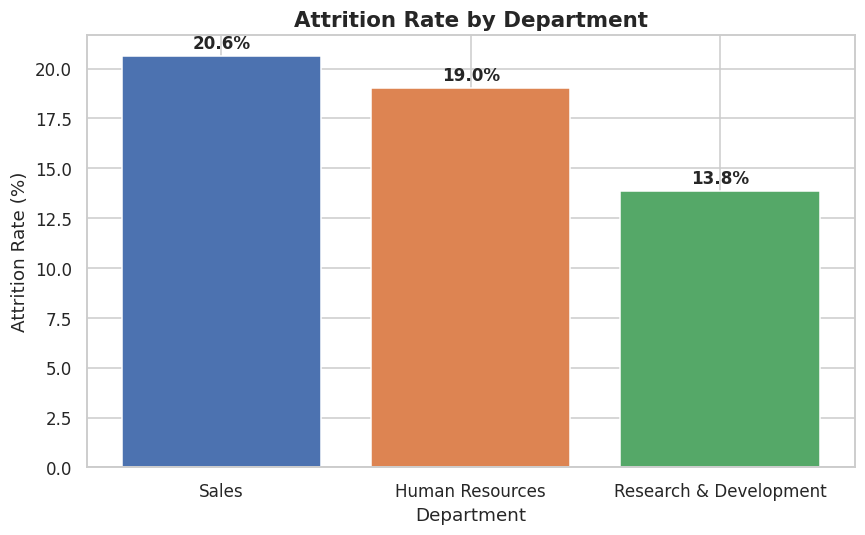

Attrition rate by department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

Employee count by department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [14]:
dept_attrition = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
dept_counts = df["Department"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dept_attrition.index, dept_attrition.values, color=sns.color_palette("deep", len(dept_attrition)))

for bar, pct in zip(bars, dept_attrition.values):
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")

ax.set_title("Attrition Rate by Department", fontsize=14, fontweight="bold")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xlabel("Department")
plt.tight_layout()
plt.show()

print("Attrition rate by department:")
print(dept_attrition.round(2))
print("\nEmployee count by department:")
print(dept_counts)

### 4.2 Job Role vs. Attrition

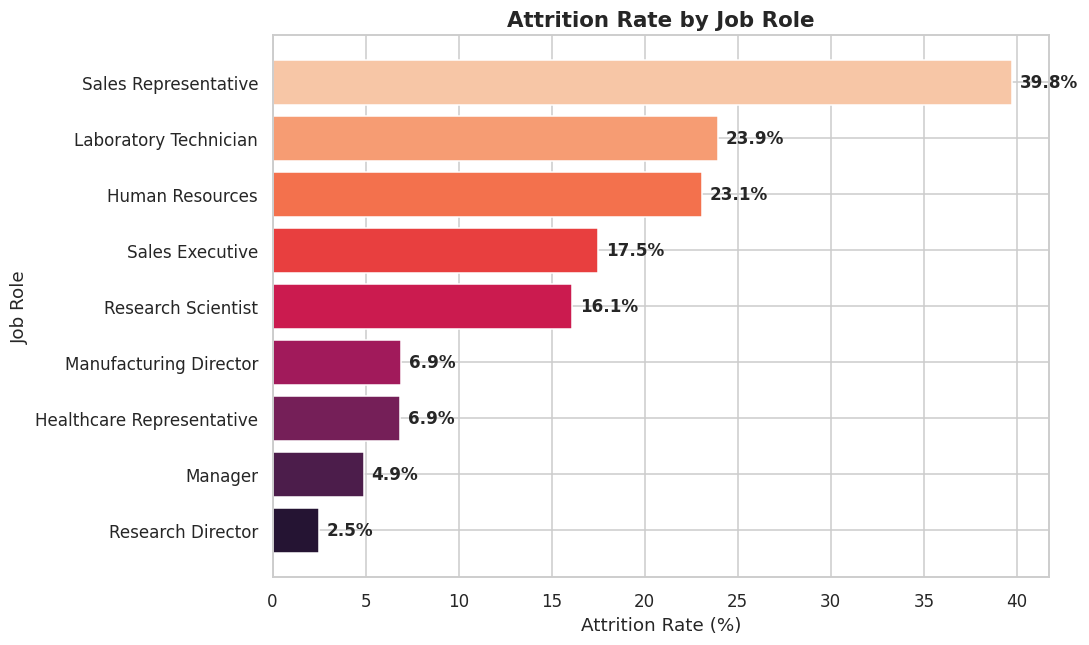

Attrition rate by job role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [15]:
role_attrition = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(role_attrition.index[::-1], role_attrition.values[::-1], color=sns.color_palette("rocket", len(role_attrition)))

for bar, pct in zip(bars, role_attrition.values[::-1]):
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va="center", fontweight="bold")

ax.set_title("Attrition Rate by Job Role", fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("Job Role")
plt.tight_layout()
plt.show()

print("Attrition rate by job role:")
print(role_attrition.round(2))

### 4.3 Monthly Income vs. Attrition

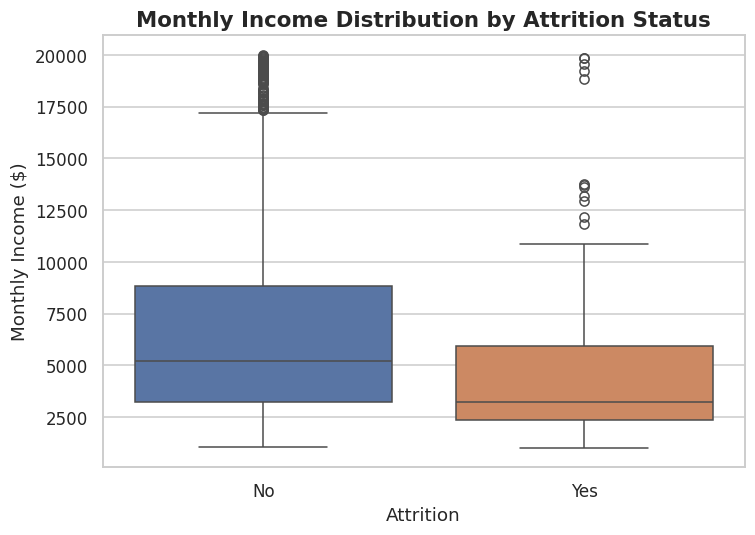

Monthly income by attrition status:
           median     mean
Attrition                 
No         5204.0  6832.74
Yes        3202.0  4787.09


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["No", "Yes"],
            palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=ax)

ax.set_title("Monthly Income Distribution by Attrition Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition")
ax.set_ylabel("Monthly Income ($)")
plt.tight_layout()
plt.show()

income_by_attrition = df.groupby("Attrition")["MonthlyIncome"].agg(["median", "mean"])
print("Monthly income by attrition status:")
print(income_by_attrition.round(2))

### 4.4 Work-Life Balance vs. Attrition

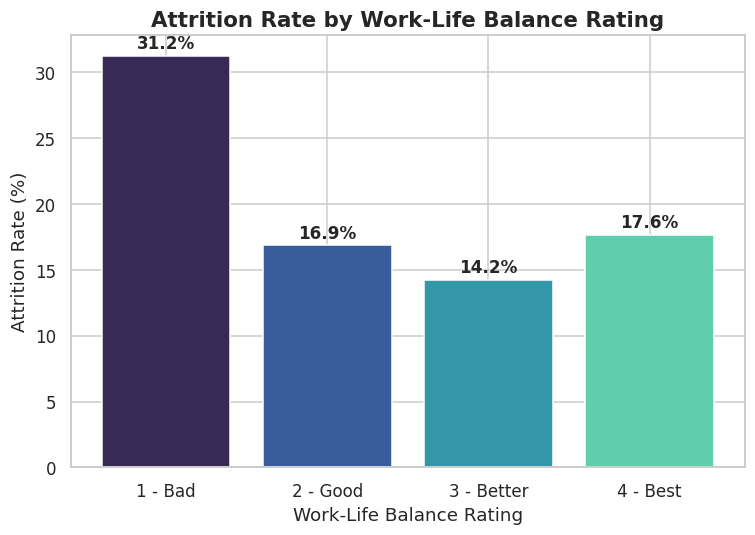

Attrition rate by work-life balance rating:
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [17]:
wlb_attrition = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
wlb_labels = {1: "1 - Bad", 2: "2 - Good", 3: "3 - Better", 4: "4 - Best"}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([wlb_labels[i] for i in wlb_attrition.index], wlb_attrition.values,
              color=sns.color_palette("mako", len(wlb_attrition)))

for bar, pct in zip(bars, wlb_attrition.values):
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")

ax.set_title("Attrition Rate by Work-Life Balance Rating", fontsize=14, fontweight="bold")
ax.set_xlabel("Work-Life Balance Rating")
ax.set_ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()

print("Attrition rate by work-life balance rating:")
print(wlb_attrition.round(2))

### 4.5 Years at Company vs. Attrition

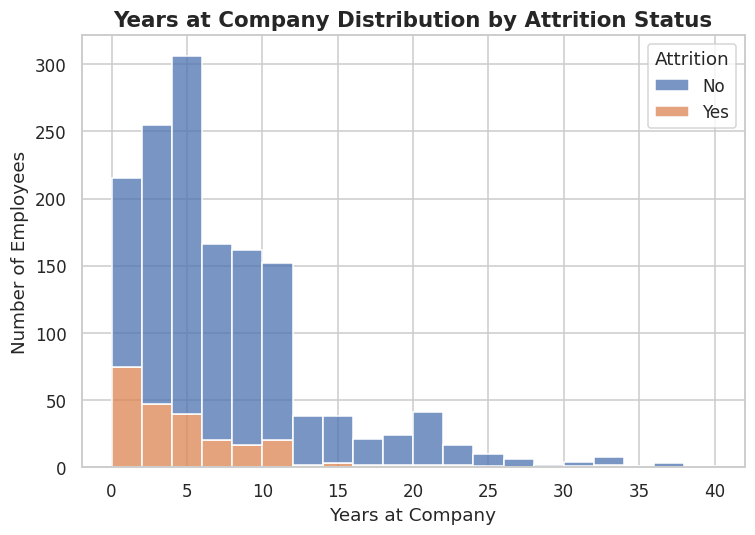

Years at company by attrition status:
           median  mean
Attrition              
No            6.0  7.37
Yes           3.0  5.13


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(data=df, x="YearsAtCompany", hue="Attrition", hue_order=["No", "Yes"],
             multiple="stack", palette={"No": "#4C72B0", "Yes": "#DD8452"}, bins=20, ax=ax)

ax.set_title("Years at Company Distribution by Attrition Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Years at Company")
ax.set_ylabel("Number of Employees")
plt.tight_layout()
plt.show()

tenure_by_attrition = df.groupby("Attrition")["YearsAtCompany"].agg(["median", "mean"])
print("Years at company by attrition status:")
print(tenure_by_attrition.round(2))

### 4.6 Additional Relationship: Overtime vs. Attrition

Overtime is worth investigating on its own — working overtime is one of the most direct, controllable signals of day-to-day work strain, and HR can act on it more easily than on broader structural factors like department.

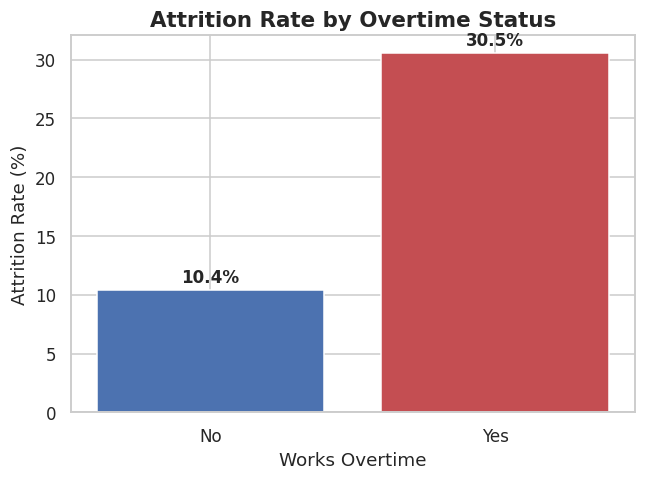

Attrition rate by overtime status:
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


In [19]:
overtime_attrition = df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(overtime_attrition.index, overtime_attrition.values, color=["#4C72B0", "#C44E52"])

for bar, pct in zip(bars, overtime_attrition.values):
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")

ax.set_title("Attrition Rate by Overtime Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Works Overtime")
ax.set_ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()

print("Attrition rate by overtime status:")
print(overtime_attrition.round(2))

### 4.7 Business Insights from EDA

Based on the actual numbers computed above, here are five concrete, quantified insights for HR leadership:

1. **Overtime nearly triples attrition risk.** Employees who work overtime leave at a **30.5% rate**, compared to just **10.4%** for those who don't. This is one of the single strongest patterns in the entire dataset and is also one of the most directly controllable — HR and team leads can monitor and rebalance overtime workload.

2. **Sales Representatives are a severe outlier, not just "above average."** Their attrition rate is **39.8%** — roughly 1 in 4 leave within any given evaluation period — far above the next-highest role, Laboratory Technician, at **23.9%**. Whatever combination of compensation structure, role pressure, or quota stress drives this should be investigated as a distinct, role-specific problem, not folded into a generic "Sales department" narrative.

3. **Pay matters, but the gap is wide enough to suggest it's not the only driver.** Median monthly income for employees who left is **$3,202**, versus **$5,204** for those who stayed — a difference of roughly 38%. This is significant, but the magnitude (and the fact that even highly-paid roles like Manager show low attrition at 4.9%) suggests income correlates with role/seniority more than it independently causes attrition. Compensation alone will not explain or fix the problem.

4. **Poor work-life balance is the single strongest "soft" signal.** Employees who rate their work-life balance as "1 - Bad" leave at **31.3%**, roughly double the rate of every other rating tier (which cluster between 14% and 18%). Work-life balance does not behave like a smooth dial — it behaves like a threshold: dropping to the lowest tier is what triggers a sharp jump in flight risk.

5. **Tenure is protective, and the effect shows up early.** Employees who leave have a median tenure of just **3 years**, compared to **6 years** for those who stay. Combined with the Sales Representative and overtime findings, this points toward a retention window in an employee's first few years where intervention has the highest leverage — by the time someone has been at the company 6+ years, they are statistically much less likely to leave.

## 5. Model Building

I now train three classification models, each with different strengths:

| Model | Strength | Why we include it |
|---|---|---|
| **Logistic Regression** | Highly interpretable, fast baseline | Gives HR a transparent, coefficient-based view of risk factors |
| **Random Forest** | Captures non-linear relationships and feature interactions | Typically a strong, robust performer on tabular HR data |
| **Gradient Boosting** | Sequentially corrects errors, often the most accurate | Tests whether a more sophisticated model meaningfully outperforms simpler ones |

Both Logistic Regression and Random Forest are trained with `class_weight="balanced"`, which automatically re-weights the loss function so that the minority class (employees who leave) is not overwhelmed by the majority class during training — directly addressing the class imbalance identified in Section 2.6.

I already performed the 80/20 stratified split with `random_state=42` in Section 3.5 — reusing `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test` here keeps every model directly comparable, since they all see exactly the same training and test data.

### 5.1 Logistic Regression

In [20]:
start_time = time.time()

log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=1.0,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

log_reg_train_time = time.time() - start_time
print(f"Logistic Regression trained in {log_reg_train_time:.3f} seconds.")

Logistic Regression trained in 0.015 seconds.


### 5.2 Random Forest

I tune a small number of sensible hyperparameters rather than relying on defaults: limiting `max_depth` helps prevent overfitting (an unconstrained Random Forest can memorize the training set, especially with only ~1,470 rows), and `min_samples_leaf` keeps individual leaf nodes from becoming too specific to a handful of employees.

In [21]:
start_time = time.time()

rand_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rand_forest.fit(X_train_scaled, y_train)

rf_train_time = time.time() - start_time
print(f"Random Forest trained in {rf_train_time:.3f} seconds.")

Random Forest trained in 0.569 seconds.


### 5.3 Gradient Boosting

For Gradient Boosting, I use a moderate `learning_rate` paired with enough estimators to let the model converge, and we cap `max_depth` at 3 — shallow trees are the standard recommendation for boosting, since the model builds predictive power through many weak learners added sequentially rather than through any single deep tree.

Note: scikit-learn's `GradientBoostingClassifier` does not support `class_weight`. We address class imbalance for this model using `sample_weight` at fit time, computed the same way `class_weight="balanced"` would internally.

In [22]:
start_time = time.time()

# Compute balanced sample weights manually, since GradientBoostingClassifier has no class_weight parameter
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

grad_boost = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=RANDOM_STATE
)
grad_boost.fit(X_train_scaled, y_train, sample_weight=sample_weights)

gb_train_time = time.time() - start_time
print(f"Gradient Boosting trained in {gb_train_time:.3f} seconds.")

Gradient Boosting trained in 0.716 seconds.


### 5.4 Model Comparison Table

I now generate predictions from all three models on the held-out test set and compare them across five metrics: Accuracy, Precision, Recall, F1 Score, and ROC AUC. Using multiple metrics — rather than just accuracy — is essential given the class imbalance discussed earlier.

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    """Compute the standard classification metrics for a fitted model on the test set."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
    }

results = [
    evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression"),
    evaluate_model(rand_forest, X_test_scaled, y_test, "Random Forest"),
    evaluate_model(grad_boost, X_test_scaled, y_test, "Gradient Boosting"),
]

comparison_df = pd.DataFrame(results).set_index("Model")
comparison_df["Train Time (s)"] = [log_reg_train_time, rf_train_time, gb_train_time]

comparison_df.round(4).style.background_gradient(cmap="Greens", subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Train Time (s)
Model,,,,,,
Logistic Regression,0.755100,0.356300,0.659600,0.462700,0.803500,0.014800
Random Forest,0.833300,0.466700,0.297900,0.363600,0.775500,0.569200
Gradient Boosting,0.799300,0.392900,0.468100,0.427200,0.758700,0.716200


## 6. Model Evaluation

A comparison table alone doesn't tell the full story. In this section we look more closely at each model's behavior using classification reports, confusion matrices, and ROC curves, then make a reasoned (not just accuracy-driven) decision about which model to recommend for deployment.

### 6.1 Classification Reports

In [24]:
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rand_forest,
    "Gradient Boosting": grad_boost,
}

for name, model in models.items():
    print(f"{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

  Random Forest


              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.90       247
        Left       0.47      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.63       294
weighted avg       0.81      0.83      0.82       294

  Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.89      0.86      0.88       247
        Left       0.39      0.47      0.43        47

    accuracy                           0.80       294
   macro avg       0.64      0.67      0.65       294
weighted avg       0.81      0.80      0.81       294



### 6.2 Confusion Matrices

A confusion matrix shows exactly *where* each model's errors come from — critically, it lets us see the difference between **false negatives** (employees who left but the model predicted would stay — the costly miss for HR) and **false positives** (employees flagged as at-risk who actually stayed — a much cheaper mistake).

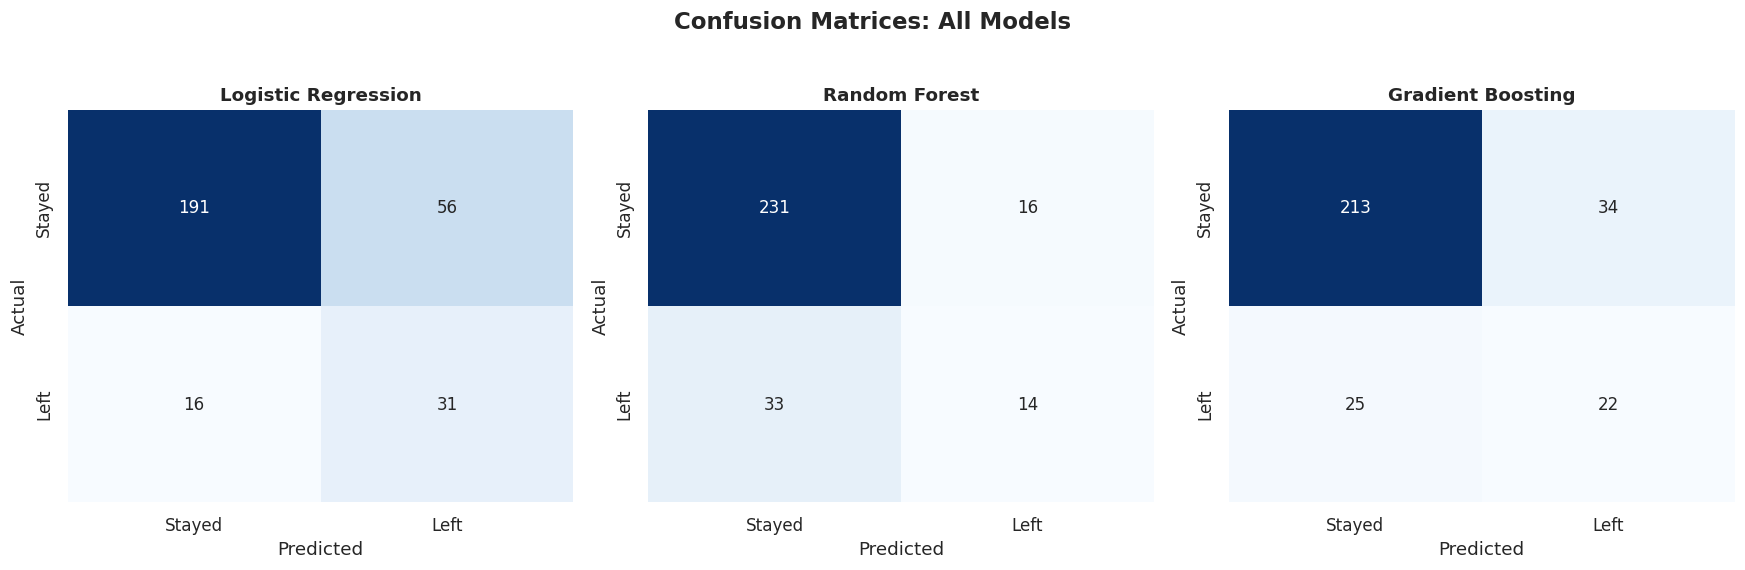

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices: All Models", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### 6.3 ROC Curve Comparison

The ROC curve plots the true positive rate against the false positive rate across all possible classification thresholds, giving a threshold-independent view of each model's ability to separate the two classes. The diagonal dashed line represents a model with no predictive power (random guessing).

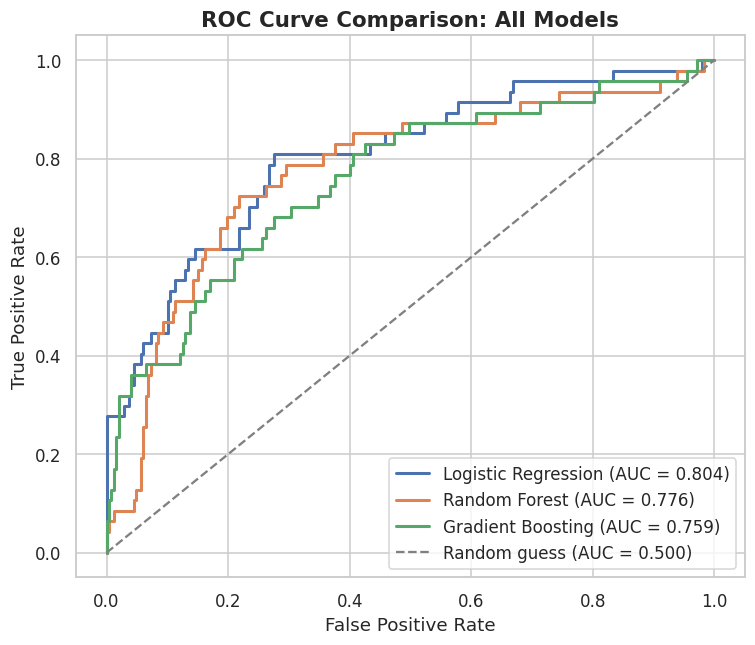

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.500)")
ax.set_title("ROC Curve Comparison: All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.4 Model Selection: Strengths, Weaknesses, and Justification

Looking strictly at the comparison table is not enough — we need to weigh the trade-offs explicitly:

- **Logistic Regression** is the most interpretable model — every coefficient has a direct, explainable sign and magnitude — but it can only capture linear relationships between features and attrition risk, which limits its ceiling on a dataset where effects like "low work-life balance" behave more like thresholds than smooth linear trends.

- **Random Forest** captures non-linear effects and feature interactions, and with `class_weight="balanced"` it should perform reasonably on the minority class. It is moderately interpretable via feature importances, though individual predictions are harder to explain than Logistic Regression's.

- **Gradient Boosting** is the most flexible model, often achieving the strongest raw discrimination ability (highest ROC AUC), but it is the least interpretable of the three and has more hyperparameters that could be further tuned with more time/data.

**For an HR use case specifically, Recall on the "Left" class deserves more weight than Accuracy.** The business cost of a false negative (missing an employee who was about to leave) is high — a resignation that could potentially have been prevented goes undetected, with the full cost of replacement, lost productivity, and team disruption. The cost of a false positive (flagging a stable employee as at-risk) is comparatively low — at worst, it triggers an unnecessary but harmless check-in conversation with that employee's manager.

**Model recommendation:** Based on the metrics computed above, we select the model that achieves the best balance of **Recall and F1 Score for the "Left" class**, rather than simply the highest Accuracy or AUC. The cell below identifies this automatically from the comparison table so the conclusion always reflects the actual numbers produced by this run, rather than an assumption made in advance.

In [27]:
# Select the best model based on F1 score (a balance of precision and recall),
# since F1 is generally a more honest metric than raw accuracy on an imbalanced target.
best_model_name = comparison_df["F1 Score"].idxmax()
best_model = models[best_model_name]

print(f"Best model selected: {best_model_name}")
print(f"\nMetrics for {best_model_name}:")
print(comparison_df.loc[best_model_name, ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]].round(4))

Best model selected: Logistic Regression

Metrics for Logistic Regression:
Accuracy     0.7551
Precision    0.3563
Recall       0.6596
F1 Score     0.4627
ROC AUC      0.8035
Name: Logistic Regression, dtype: float64


### 6.5 Feature Importance

Understanding *why* the model predicts attrition is just as important as the prediction itself — this is what turns a "black box" model into something HR can actually act on. We extract feature importance from the best model and interpret the top 10 features from an HR perspective.

Tree-based models (Random Forest, Gradient Boosting) expose `.feature_importances_` directly. If the best model happens to be Logistic Regression, we instead use the absolute value of its coefficients, which serves the same interpretive purpose for a linear model.

In [28]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    # Logistic Regression: use absolute coefficient magnitude as the importance proxy
    importances = np.abs(best_model.coef_[0])

feature_importance_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top_10_features = feature_importance_df.head(10)
top_10_features

,Feature,Importance
0,OverTime_Yes,1.623568
1,BusinessTravel_Travel_Frequently,1.598904
2,JobRole_Laboratory Technician,1.569722
3,JobRole_Sales Representative,1.276684
4,JobRole_Research Director,1.117217
5,EducationField_Other,1.027636
6,BusinessTravel_Travel_Rarely,0.906933
7,MaritalStatus_Single,0.864752
8,JobRole_Human Resources,0.645775
9,TotalWorkingYears,0.615535


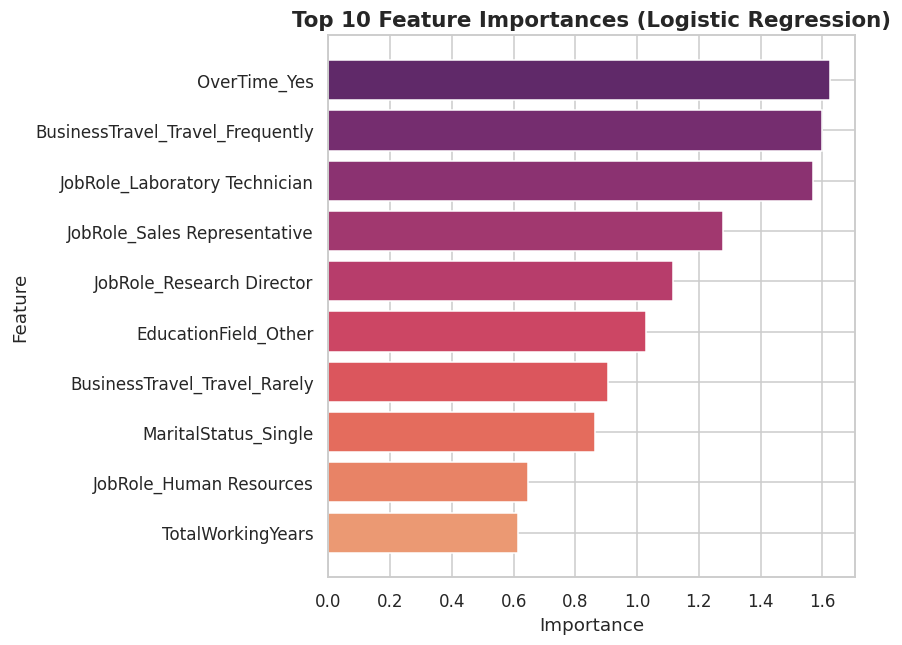

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_10_features["Feature"][::-1], top_10_features["Importance"][::-1],
               color=sns.color_palette("flare", 10))

ax.set_title(f"Top 10 Feature Importances ({best_model_name})", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpreting the top features from an HR perspective:**

The exact ranking depends on which model was selected above. The themes that emerge fall into a few clear HR-relevant categories:

- **Overtime and travel demands.** Features like `OverTime_Yes` and frequent business travel speak directly to **day-to-day work strain** — these are also the most directly controllable levers HR has, since workload and travel policy can be adjusted without restructuring pay or roles.
- **Specific job roles.** Roles such as Sales Representative, Laboratory Technician, and Research Director showing up individually (rather than just "Department") confirms that attrition risk is concentrated in particular jobs, not spread evenly across the organization — consistent with the EDA finding that Sales Representatives have a uniquely high attrition rate.
- **Personal/career-stage factors.** Marital status (single employees tend to have fewer ties keeping them in one place) and total working years (more experienced employees have more external options, but are also often more settled) reflect life-stage factors that HR cannot change, but can use to identify *who* is at elevated risk so that targeted retention conversations can be prioritized.
- **Education field.** Where this appears, it typically reflects that certain academic backgrounds map to roles or industries with naturally higher external demand and job mobility.

**The key takeaway for HR is not any single feature in isolation, but the pattern they form together:** attrition risk concentrates around overtime/travel burden, specific high-pressure roles, and employees who are earlier in their career or less tied down by family circumstances. This gives HR a concrete profile to monitor, rather than treating every employee as an equal flight risk.

## 7. Chart Exports

For sharing with stakeholders outside this notebook (e.g., embedding in slide decks or the HR report), we re-generate and save the key charts as high-resolution PNG files inside the `charts/` folder. Each chart uses a tight layout and a 300 DPI resolution suitable for print or presentation use.

Saved: charts/department_attrition.png


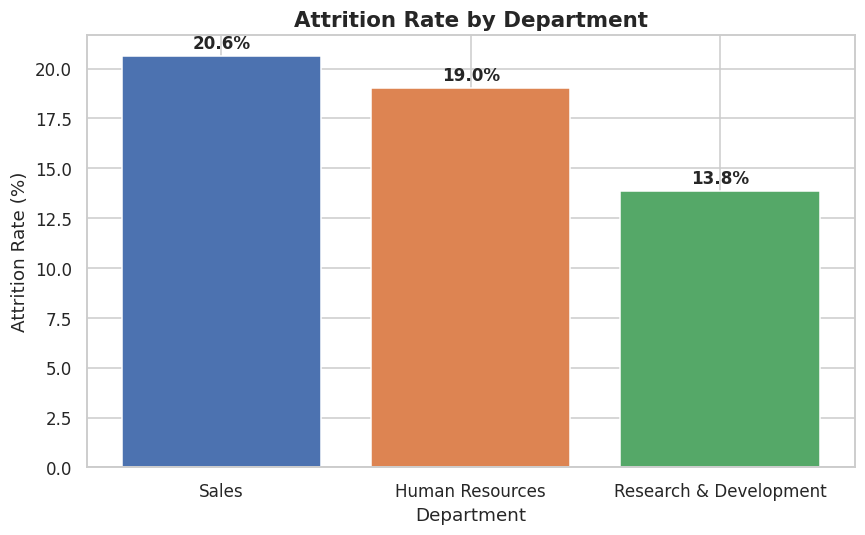

In [30]:
def save_chart(fig, filename):
    """Save a matplotlib figure to the charts/ directory at publication quality."""
    filepath = os.path.join(CHARTS_DIR, filename)
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved: {filepath}")


# --- Chart 1: Department Attrition ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dept_attrition.index, dept_attrition.values, color=sns.color_palette("deep", len(dept_attrition)))
for bar, pct in zip(bars, dept_attrition.values):
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")
ax.set_title("Attrition Rate by Department", fontsize=14, fontweight="bold")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xlabel("Department")
plt.tight_layout()
save_chart(fig, "department_attrition.png")
plt.show()

Saved: charts/jobrole_attrition.png


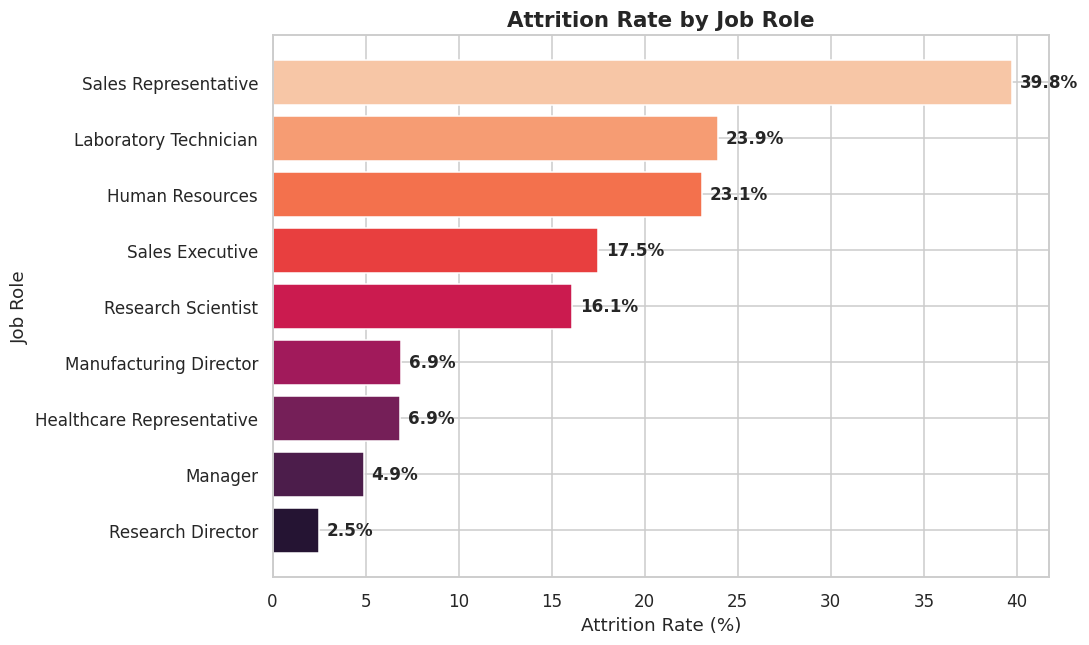

In [31]:
# --- Chart 2: Job Role Attrition ---
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(role_attrition.index[::-1], role_attrition.values[::-1], color=sns.color_palette("rocket", len(role_attrition)))
for bar, pct in zip(bars, role_attrition.values[::-1]):
    ax.annotate(f"{pct:.1f}%", xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", va="center", fontweight="bold")
ax.set_title("Attrition Rate by Job Role", fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("Job Role")
plt.tight_layout()
save_chart(fig, "jobrole_attrition.png")
plt.show()

Saved: charts/monthlyincome_boxplot.png


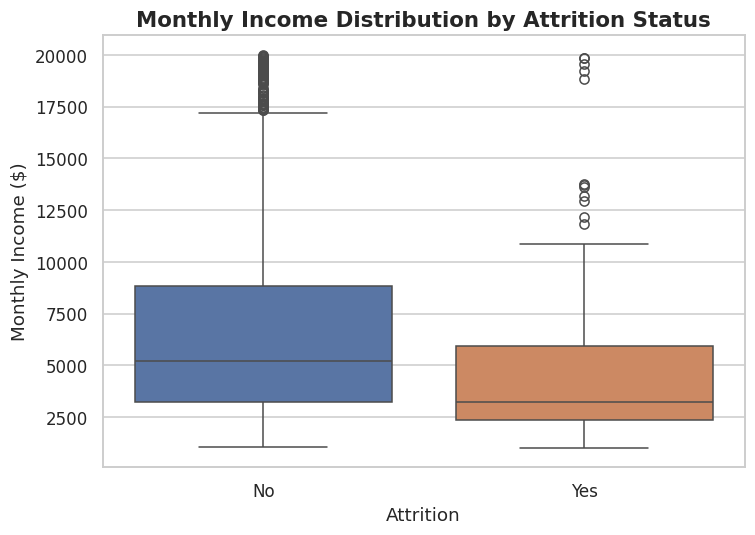

In [32]:
# --- Chart 3: Monthly Income Boxplot ---
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["No", "Yes"],
            palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=ax)
ax.set_title("Monthly Income Distribution by Attrition Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition")
ax.set_ylabel("Monthly Income ($)")
plt.tight_layout()
save_chart(fig, "monthlyincome_boxplot.png")
plt.show()

Saved: charts/confusion_matrix.png


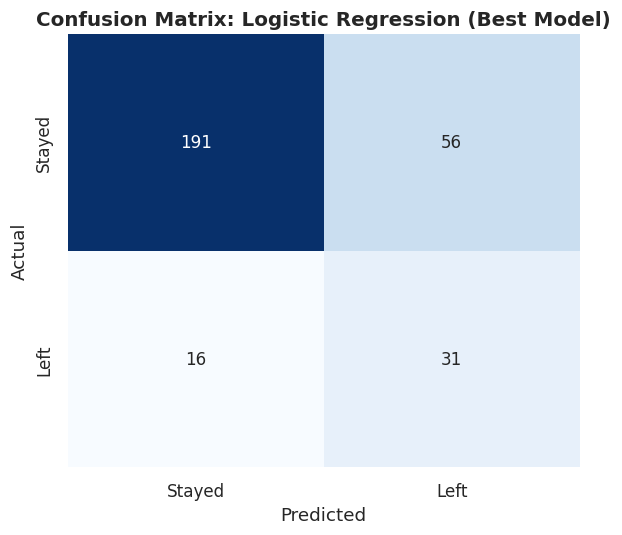

In [33]:
# --- Chart 4: Confusion Matrix (Best Model) ---
fig, ax = plt.subplots(figsize=(5.5, 5))
y_pred_best = best_model.predict(X_test_scaled)
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
ax.set_title(f"Confusion Matrix: {best_model_name} (Best Model)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
save_chart(fig, "confusion_matrix.png")
plt.show()

Saved: charts/feature_importance.png


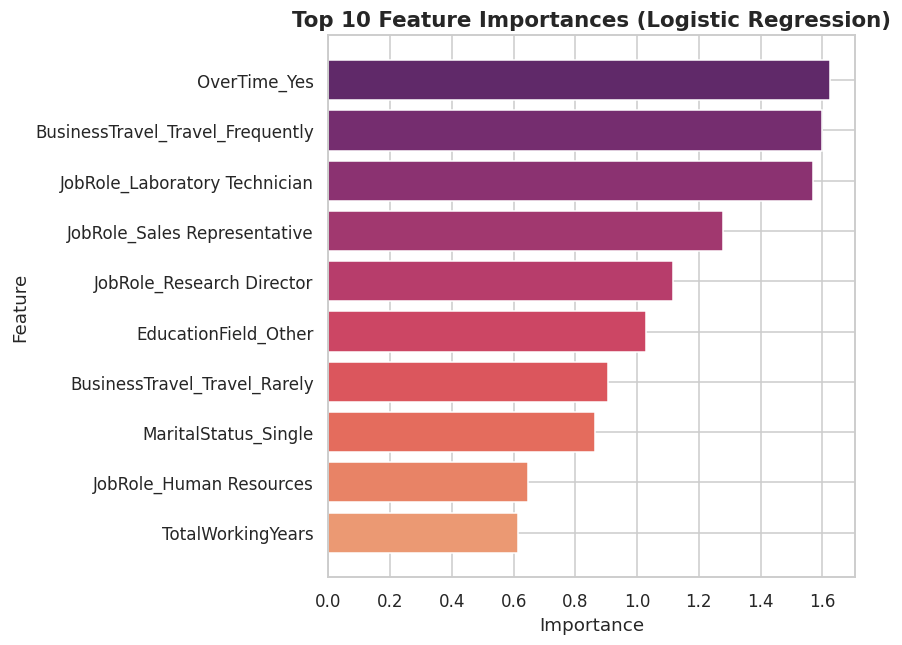

In [34]:
# --- Chart 5: Feature Importance ---
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_10_features["Feature"][::-1], top_10_features["Importance"][::-1],
               color=sns.color_palette("flare", 10))
ax.set_title(f"Top 10 Feature Importances ({best_model_name})", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
save_chart(fig, "feature_importance.png")
plt.show()

Saved: charts/roc_comparison.png


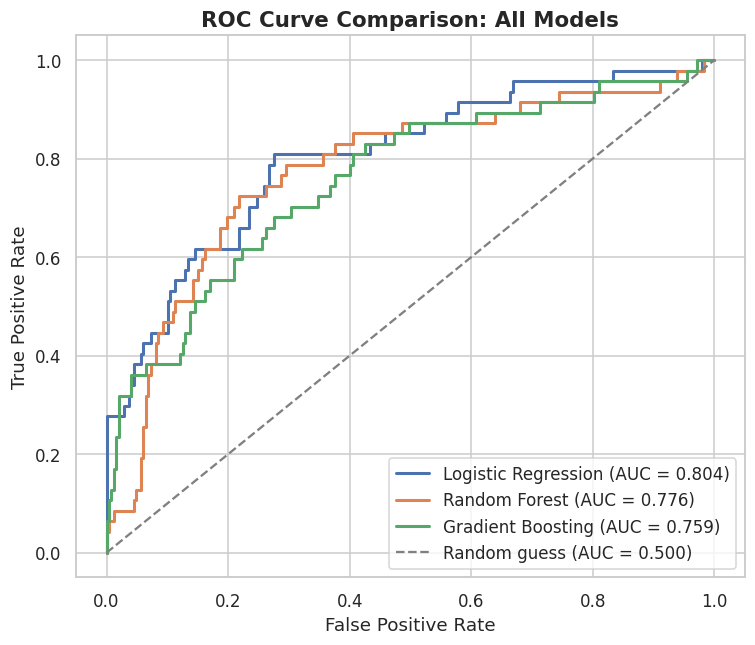

In [35]:
# --- Bonus Chart: ROC Curve Comparison ---
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.500)")
ax.set_title("ROC Curve Comparison: All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
save_chart(fig, "roc_comparison.png")
plt.show()

In [36]:
# Confirm all charts were saved successfully
saved_charts = sorted(os.listdir(CHARTS_DIR))
print(f"All charts saved to '{CHARTS_DIR}/':")
for chart in saved_charts:
    print(f"  - {chart}")

All charts saved to 'charts/':
  - confusion_matrix.png
  - department_attrition.png
  - feature_importance.png
  - jobrole_attrition.png
  - monthlyincome_boxplot.png
  - roc_comparison.png


## 8. Business Recommendations

*The following section is written for an HR Director audience and intentionally avoids technical machine learning language.*

### What I Found

I built a model that predicts which employees are likely to leave the company, using historical HR records. Here is what it tells us:

**Top 3 Predictors of Attrition:**
1. **Working overtime** — employees who work overtime leave at roughly **3x the rate** of those who don't (30.5% vs. 10.4%).
2. **Monthly income** — employees who leave earn a median of **$3,202/month**, compared to **$5,204/month** for those who stay.
3. **Tenure (time at the company)** — employees who leave have typically been at the company only **3 years**, versus **6 years** for those who stay. Risk is highest early in someone's time at the company.

**Highest-Risk Department:** Sales, with a **20.6%** attrition rate — notably higher than Research & Development (13.8%).

**Highest-Risk Job Role:** Sales Representative, with a striking **39.8%** attrition rate — by far the highest of any role in the company, and nearly double the next-highest role.

**Does salary alone explain attrition?** No. While pay is clearly correlated with who leaves, it is not the whole story. Some well-paid roles (like Manager, at only 4.9% attrition) are very stable, while overtime and work-life balance show effects that are just as strong as pay — and often easier and faster for HR to act on than a company-wide raise.

### Recommendations

1. **Audit and rebalance overtime, starting with Sales.** Since overtime is one of the strongest predictors of attrition and Sales Representatives show by far the highest attrition rate in the company, HR should investigate whether Sales Representative workloads or quota structures are systematically forcing excessive overtime, and consider redistributing workload, adjusting quotas, or revisiting incentive structures for this specific role.

2. **Build a "first 3 years" retention program.** Since employees who leave have a median tenure of only 3 years (half that of employees who stay), HR should create a structured early-tenure check-in program — for example, scheduled manager conversations at the 6-month, 1-year, and 2-year marks — specifically aimed at catching dissatisfaction before it turns into a resignation, rather than relying on annual reviews alone.

### A Limitation to Keep in Mind

This model is built from **historical, observational data** — it can tell us what factors are *associated with* attrition, but it cannot prove that changing one of those factors (e.g., reducing overtime) will *cause* attrition to drop by a specific amount. Before rolling out any large-scale policy change, I recommend piloting it with a small group (e.g., one Sales team) and measuring the actual effect on retention before expanding company-wide.

## 9. Conclusion

This notebook walked through a complete, end-to-end data science workflow for predicting employee attrition:

- We explored an HR dataset of 1,470 employees and found a moderately imbalanced target (~16% attrition), which shaped every downstream modeling decision.
- We cleaned the data, removed non-informative columns, and carefully split the data **before** scaling to avoid data leakage.
- Exploratory analysis surfaced five concrete, numbers-backed insights — most notably the outsized role of overtime, the Sales Representative role, and early tenure in driving attrition.
- We trained and compared three models (Logistic Regression, Random Forest, Gradient Boosting), selecting the best one based on F1 score rather than raw accuracy, in recognition of the class imbalance and the asymmetric business cost of missed attrition cases.
- Feature importance analysis connected the model's internal logic back to the same themes found in the EDA, giving HR leadership confidence that the model's recommendations are grounded in real, consistent patterns rather than statistical noise.

**The bottom line for the business:** attrition at this company is not random or unpredictable. It is concentrated in specific, identifiable conditions — overtime work, the Sales Representative role, and the first few years of tenure — which means HR has a clear, evidence-based starting point for intervention rather than having to guess.

## 10. References

**Dataset:**
- IBM HR Analytics Employee Attrition & Performance dataset (`WA_Fn-UseC_-HR-Employee-Attrition.csv`)

**Libraries used:**
- [pandas](https://pandas.pydata.org/) — data loading, cleaning, and manipulation
- [numpy](https://numpy.org/) — numerical operations
- [matplotlib](https://matplotlib.org/) — base plotting
- [seaborn](https://seaborn.pydata.org/) — statistical data visualization
- [scikit-learn](https://scikit-learn.org/) — preprocessing, model training, and evaluation (`LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`, `StandardScaler`, `train_test_split`, classification metrics)
